# Análisis de Precio y Abastecimiento — Papa Superior Corabastos (2019–2025)

**Objetivo:** Identificar qué variables explican el precio de la papa Superior en Corabastos, partiendo de la hipótesis de que el abastecimiento es el principal determinante.

**Fuentes de datos:**
- Abastecimiento: SIPSA — DANE (2013–2025)
- Precios: SIPSA — DANE (2013–2026)
- IPC Alimentos: Banco de la República (2019–2025)

**Estructura del análisis:**
1. Limpieza y preparación de datos 
2. Análisis descriptivo
3. Correlación precio vs abastecimiento
4. Incorporación del IPC y precio real
5. Estacionalidad
6. Modelos explicativos del precio

---
## 0. Librerías y configuración

In [ ]:
# --- CELDA DE PRUEBA PUSH/PULL ---
print("Esta celda es una prueba de push y pull con Git")
print("Si ves esto después de un pull — funcionó correctamente ✅")
print("Prueba Farith ")
print("prueba laex ")


Esta celda es una prueba de push y pull con Git
Si ves esto después de un pull — funcionó correctamente ✅


In [2]:
# --- Librerías de manipulación de datos ---
import pandas as pd       # manejo de dataframes
import numpy as np        # operaciones numéricas

# --- Librerías de visualización ---
import matplotlib.pyplot as plt          # gráficas base
import matplotlib.ticker as mticker      # formato de ejes
import seaborn as sns                    # gráficas estadísticas

# --- Librerías estadísticas ---
from scipy import stats                              # correlaciones Pearson y Spearman
from statsmodels.tsa.seasonal import seasonal_decompose  # descomposición de series de tiempo

# --- Librerías de machine learning ---
from sklearn.linear_model import LinearRegression        # regresión lineal
from sklearn.metrics import mean_absolute_error, mean_squared_error  # métricas del modelo

# --- Configuración visual global ---
sns.set_theme(style='whitegrid')          # estilo de fondo para todas las gráficas
plt.rcParams['figure.dpi'] = 120          # resolución de las gráficas
plt.rcParams['font.family'] = 'sans-serif'

# --- RUTAS DE ARCHIVOS ---
# Carpeta con los archivos originales sin modificar
#RAW       = r"C:\Users\anaso\OneDrive\Desktop\Analisis de Datos 2026\proyecto_papa_superior_corabastos\data\raw"
#PROCESSED = r"C:\Users\anaso\OneDrive\Desktop\Analisis de Datos 2026\proyecto_papa_superior_corabastos\data\processed"

# --- ORDEN CORRECTO DE LOS MESES EN ESPAÑOL ---

import os

# Ruta base = carpeta donde está el notebook
BASE = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()

# Subir un nivel desde notebooks/ para llegar a la raíz del proyecto
ROOT = os.path.dirname(BASE)

# Rutas relativas — funcionan en cualquier PC
RAW       = os.path.join(ROOT, 'data', 'raw')
PROCESSED = os.path.join(ROOT, 'data', 'processed')

print("RAW:", RAW)
print("PROCESSED:", PROCESSED)
# Se define aquí para reutilizarlo en todo el proyecto
meses_orden = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

# Diccionario para convertir nombre de mes a número (ej: 'Enero' → '01')
# Se usa para construir fechas en formato datetime
mes_num = {m: str(i+1).zfill(2) for i, m in enumerate(meses_orden)}

print('✅ Librerías cargadas correctamente')

RAW: c:\Users\User\Desktop\Analisis de datos 2026\proyecto_papa_superior-\data\raw
PROCESSED: c:\Users\User\Desktop\Analisis de datos 2026\proyecto_papa_superior-\data\processed
✅ Librerías cargadas correctamente


---
## 1. Limpieza y preparación de datos

En esta sección cargamos los datos crudos, corregimos errores de formato, filtramos solo lo que necesitamos (Corabastos, papa Superior, 2019–2025) y construimos el dataset maestro mensual.

In [3]:
# --- Cargar los dos archivos originales sin modificar nada aún ---

# El CSV de abastecimiento requiere encoding='latin1' porque contiene tildes
# y caracteres especiales que el encoding por defecto (UTF-8) no lee bien
df_abast_raw = pd.read_csv(
    f"{RAW}\\ABASTECIMIENTO_PAPA_2013_2025.csv",
    encoding='latin1'
)

# El archivo de precios está en formato Excel con una sola hoja llamada 'Base Papa'
df_precios_raw = pd.read_excel(
    f"{RAW}\\Base_Precios_historica_13_2026.xlsx",
    sheet_name='Base Papa'
)

print("Abastecimiento shape:", df_abast_raw.shape)
print("Precios shape:", df_precios_raw.shape)

Abastecimiento shape: (888086, 12)
Precios shape: (86898, 11)


In [4]:
# --- Limpiar el dataset de abastecimiento ---

# Trabajamos sobre una copia para no modificar el original
df_abast = df_abast_raw.copy()

# Problema 1: La columna 'Año' llegó con encoding roto → aparece como 'AÃ±o'
# Solución: renombramos todas las columnas manualmente con los nombres correctos
df_abast.columns = [
    'Central', 'fecha', 'Cod_Depto', 'Cod_Mun',
    'Departamento', 'Municipio', 'variedad',
    'semana', 'Año', 'CantKg', 'mes', 'Toneladas'
]

# Problema 2: La columna 'mes' tiene inconsistencia de capitalización
# Todos los meses están con primera letra mayúscula EXCEPTO 'julio' que está en minúscula
# Solución: str.capitalize() pone la primera letra en mayúscula y el resto en minúscula
df_abast['mes'] = df_abast['mes'].str.capitalize()

# Problema 3: La columna 'fecha' llegó como texto (string) en formato 'dd/mm/yyyy'
# Solución: convertirla a tipo datetime para poder operar con fechas
df_abast['fecha'] = pd.to_datetime(df_abast['fecha'], format='%d/%m/%Y')

print("✅ Abastecimiento limpio")
print(df_abast.dtypes)

✅ Abastecimiento limpio
Central                    str
fecha           datetime64[us]
Cod_Depto                  str
Cod_Mun                    str
Departamento               str
Municipio                  str
variedad                   str
semana                   int64
Año                      int64
CantKg                 float64
mes                        str
Toneladas              float64
dtype: object


In [5]:
# --- Filtrar abastecimiento: solo Corabastos + papa Superior + 2019 a 2025 ---

# Aplicamos tres filtros simultáneos:
# 1. Central == 'Corabastos' → la plaza mayorista de Bogotá
# 2. variedad == 'Superior'  → la variedad de interés
# 3. Año entre 2019 y 2025   → el período de análisis
df_abast_filtrado = df_abast[
    (df_abast['Central']  == 'Corabastos') &
    (df_abast['variedad'] == 'Superior') &
    (df_abast['Año'].between(2019, 2025))
].copy()

print("Filas después del filtro:", df_abast_filtrado.shape[0])
print("Años disponibles:", sorted(df_abast_filtrado['Año'].unique()))

Filas después del filtro: 53863
Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [6]:
# --- Limpiar el dataset de precios ---

# Trabajamos sobre una copia para no modificar el original
df_precios = df_precios_raw.copy()

# La columna 'mes' en precios está en minúscula ('enero', 'febrero'...)
# La capitalizamos para que coincida con el formato del dataset de abastecimiento
# y poder hacer el merge correctamente más adelante
df_precios['mes'] = df_precios['mes'].str.capitalize()

# Filtrar: solo Bogotá D.C. + variedad Superior + 2019-2025
# Nota: usamos 'Bogotá D.C.' como proxy de Corabastos porque los precios
# institucionales del SIPSA se capturan en Corabastos para Bogotá
df_precios_filtrado = df_precios[
    (df_precios['ciudad']   == 'Bogotá D.C.') &
    (df_precios['variedad'] == 'Superior') &
    (df_precios['year'].between(2019, 2025))
].copy()

# Quedarse solo con las columnas útiles y renombrar para consistencia
df_precios_filtrado = df_precios_filtrado[
    ['year', 'mes', 'semana', 'fecha3', 'precio']
].rename(columns={'year': 'Año', 'fecha3': 'fecha'})

print("✅ Precios limpios")
print("Filas después del filtro:", df_precios_filtrado.shape[0])
print("Años disponibles:", sorted(df_precios_filtrado['Año'].unique()))

✅ Precios limpios
Filas después del filtro: 366
Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [7]:
# --- Agregar ambos datasets a nivel mensual ---

# El abastecimiento está a nivel diario → sumamos las toneladas por mes
abast_mensual = df_abast_filtrado.groupby(
    ['Año', 'mes'], as_index=False
)['Toneladas'].sum()

# Los precios están a nivel semanal → promediamos el precio por mes
precios_mensual = df_precios_filtrado.groupby(
    ['Año', 'mes'], as_index=False
)['precio'].mean().rename(columns={'precio': 'precio_promedio'})

print("Abastecimiento mensual:", abast_mensual.shape)
print("Precios mensual:", precios_mensual.shape)

Abastecimiento mensual: (84, 3)
Precios mensual: (84, 3)


In [8]:
# --- Crear el dataset maestro uniendo ambas fuentes ---

# Unimos por Año y mes (inner join = solo filas que existen en ambos)
df_maestro = pd.merge(abast_mensual, precios_mensual, on=['Año', 'mes'], how='inner')

# Convertimos la columna 'mes' a tipo Categorical con el orden correcto
# Sin esto, pandas ordenaría los meses alfabéticamente (Abril, Agosto, Diciembre...)
df_maestro['mes'] = pd.Categorical(df_maestro['mes'], categories=meses_orden, ordered=True)

# Ordenar cronológicamente
df_maestro = df_maestro.sort_values(['Año', 'mes']).reset_index(drop=True)

# Guardar en CSV (para Power BI) y Parquet (para los siguientes notebooks, más eficiente)
df_maestro.to_csv(f"{PROCESSED}\\papa_superior_corabastos_2019_2025.csv", index=False)
df_maestro.to_parquet(f"{PROCESSED}\\papa_superior_corabastos_2019_2025.parquet", index=False)

print("✅ Dataset maestro creado:", df_maestro.shape)
print("   84 filas = 7 años × 12 meses")
print("   4 columnas: Año, mes, Toneladas, precio_promedio")
df_maestro.head(12)

✅ Dataset maestro creado: (84, 4)
   84 filas = 7 años × 12 meses
   4 columnas: Año, mes, Toneladas, precio_promedio


,Año,mes,Toneladas,precio_promedio
0,2019,Enero,21718.850015,772.680206
1,2019,Febrero,17933.900006,798.444778
2,2019,Marzo,20840.399999,871.406474
3,2019,Abril,17516.300000,1136.499939
4,2019,Mayo,23682.049977,1056.201807
5,2019,Junio,21918.900008,1109.630905
6,2019,Julio,25005.699938,995.908630
7,2019,Agosto,28274.599963,843.370496
8,2019,Septiembre,24041.699974,809.094650
9,2019,Octubre,25030.500007,855.990463


---
## 2. Análisis Descriptivo

Exploramos el comportamiento general del precio y el abastecimiento año a año y mes a mes.

In [9]:
# --- Estadísticas básicas por año ---
# Calculamos métricas clave para cada año: mínimo, máximo, promedio,
# desviación estándar (volatilidad), total y promedio mensual de toneladas
resumen = df_maestro.groupby('Año').agg(
    precio_min      = ('precio_promedio', 'min'),
    precio_max      = ('precio_promedio', 'max'),
    precio_medio    = ('precio_promedio', 'mean'),
    precio_std      = ('precio_promedio', 'std'),    # desviación estándar = volatilidad del precio
    toneladas_total = ('Toneladas', 'sum'),
    toneladas_media = ('Toneladas', 'mean')
).round(2)

# Guardar para usar en Power BI
resumen.to_csv(f"{PROCESSED}\\resumen_anual.csv")
print(resumen.to_string())

      precio_min  precio_max  precio_medio  precio_std  toneladas_total  toneladas_media
Año                                                                                     
2019      619.28     1136.50        890.14      153.56        273450.90         22787.57
2020      479.90     1081.97        718.30      194.30        240519.20         20043.27
2021      616.30     1491.87        975.96      270.57        276383.85         23031.99
2022      785.12     2577.62       1539.26      647.37        322754.35         26896.20
2023      925.62     1890.91       1385.75      282.32        322211.25         26850.94
2024     1195.65     2650.73       1714.86      506.34        291497.48         24291.46
2025      565.24     1735.54       1000.45      378.60        274617.05         22884.75


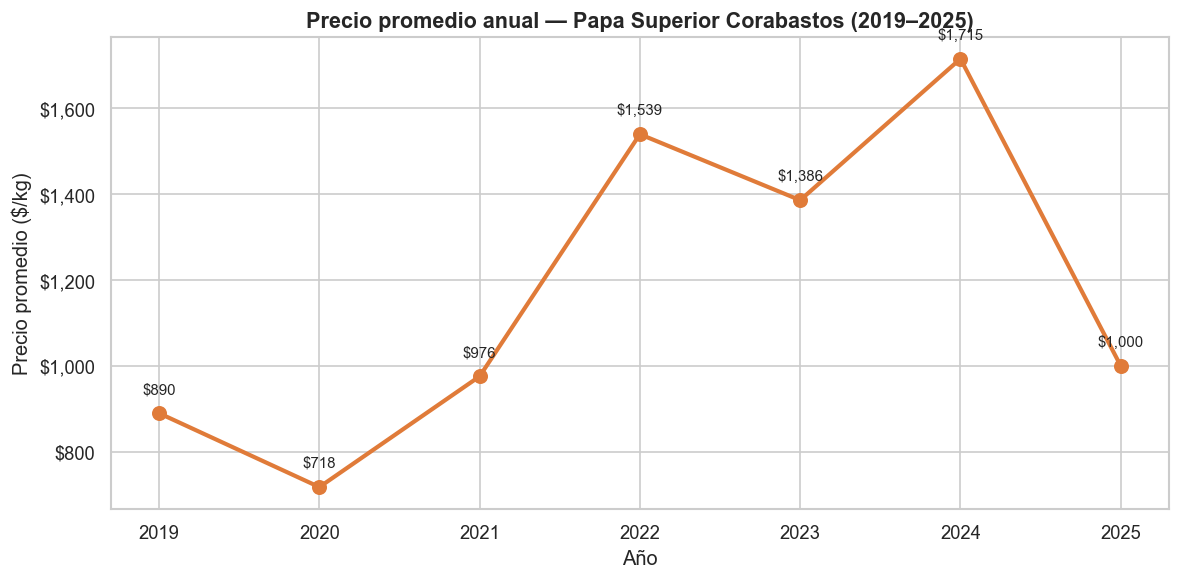

In [10]:
# --- Gráfica 1: Evolución anual del precio promedio ---
# Muestra la tendencia general del precio año a año
precio_anual = df_maestro.groupby('Año')['precio_promedio'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

# Línea con puntos en cada año
ax.plot(precio_anual['Año'], precio_anual['precio_promedio'],
        marker='o', linewidth=2.5, color='#E07B39', markersize=8)

# Etiquetas de valor encima de cada punto
for _, row in precio_anual.iterrows():
    ax.annotate(f"${row['precio_promedio']:,.0f}",
                xy=(row['Año'], row['precio_promedio']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_title('Precio promedio anual — Papa Superior Corabastos (2019–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Precio promedio ($/kg)')
# Formato de eje Y con símbolo de peso y separador de miles
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticks(precio_anual['Año'])
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_precio_anual.png", bbox_inches='tight')
plt.show()

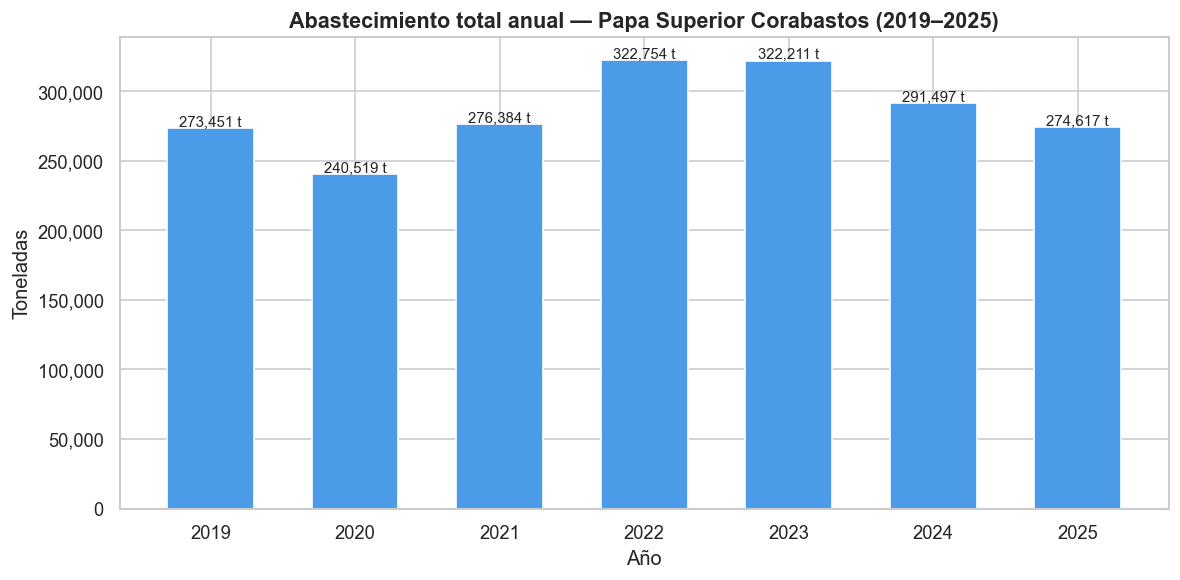

In [11]:
# --- Gráfica 2: Abastecimiento total anual ---
# Muestra cuántas toneladas de papa Superior entraron a Corabastos cada año
abast_anual = df_maestro.groupby('Año')['Toneladas'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

# Gráfica de barras
bars = ax.bar(abast_anual['Año'], abast_anual['Toneladas'],
              color='#4C9BE8', width=0.6, edgecolor='white')

# Etiquetas encima de cada barra con el total en toneladas
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1500,
            f"{bar.get_height():,.0f} t",
            ha='center', fontsize=9)

ax.set_title('Abastecimiento total anual — Papa Superior Corabastos (2019–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Toneladas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(abast_anual['Año'])
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_abastecimiento_anual.png", bbox_inches='tight')
plt.show()

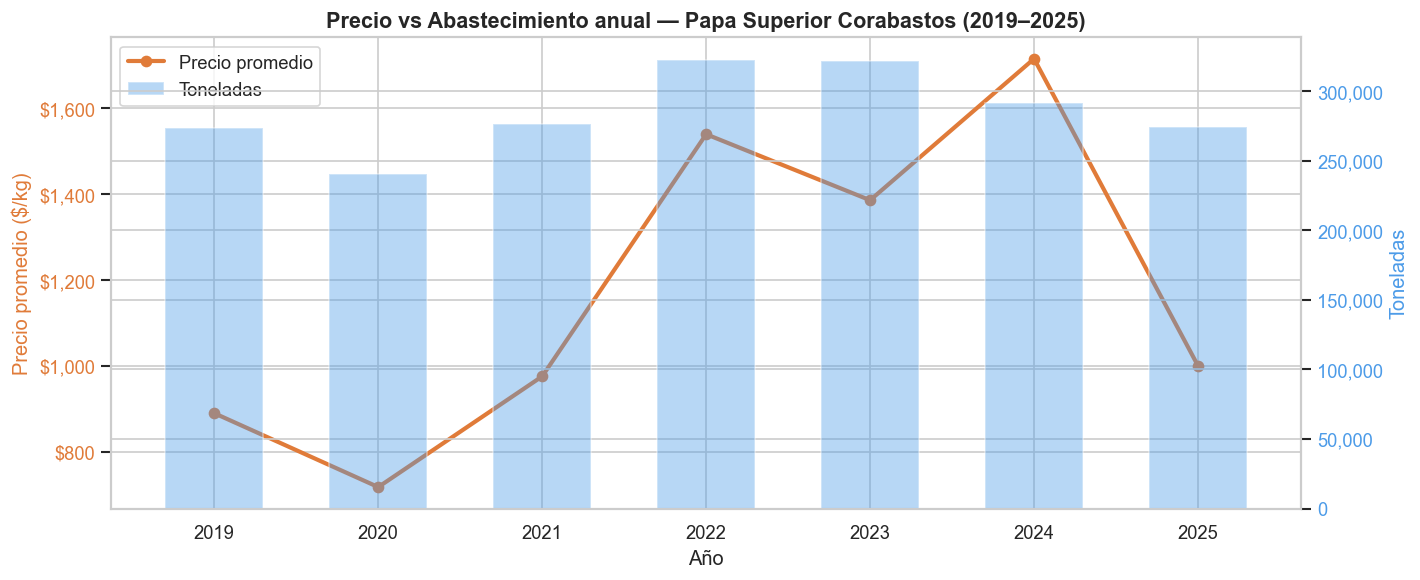

In [12]:
# --- Gráfica 3: Precio y abastecimiento en doble eje ---
# Esta gráfica combina precio (línea) y toneladas (barras) en el mismo panel
# usando dos ejes Y independientes, uno a cada lado
fig, ax1 = plt.subplots(figsize=(12, 5))

# Eje izquierdo: precio (línea naranja)
color_precio = '#E07B39'
ax1.plot(precio_anual['Año'], precio_anual['precio_promedio'],
         marker='o', color=color_precio, linewidth=2.5, label='Precio promedio')
ax1.set_ylabel('Precio promedio ($/kg)', color=color_precio)
ax1.tick_params(axis='y', labelcolor=color_precio)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Eje derecho: abastecimiento (barras azules)
ax2 = ax1.twinx()   # crea un segundo eje Y compartiendo el mismo eje X
color_abast = '#4C9BE8'
ax2.bar(abast_anual['Año'], abast_anual['Toneladas'],
        color=color_abast, alpha=0.4, width=0.6, label='Toneladas')
ax2.set_ylabel('Toneladas', color=color_abast)
ax2.tick_params(axis='y', labelcolor=color_abast)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax1.set_title('Precio vs Abastecimiento anual — Papa Superior Corabastos (2019–2025)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Año')
ax1.set_xticks(precio_anual['Año'])

# Combinamos las leyendas de los dos ejes en una sola
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_precio_vs_abastecimiento.png", bbox_inches='tight')
plt.show()

---
## 3. Correlación Precio vs Abastecimiento

**Hipótesis inicial:** A mayor abastecimiento, menor precio.

Usamos dos tipos de correlación:
- **Pearson:** mide relación lineal directa entre dos variables (-1 a 1)
- **Spearman:** mide relación de orden, más robusta cuando los datos no son perfectamente lineales

Un valor cercano a 0 indica correlación débil. Cercano a -1 o 1 indica correlación fuerte.

In [14]:
# --- Calcular correlaciones a nivel mensual ---

# Pearson: correlación lineal entre toneladas y precio
pearson_m,  p_pearson_m  = stats.pearsonr(df_maestro['Toneladas'], df_maestro['precio_promedio'])
# Spearman: correlación por rangos (más robusta a outliers)
spearman_m, p_spearman_m = stats.spearmanr(df_maestro['Toneladas'], df_maestro['precio_promedio'])

# Correlación con rezago de 1 mes:
# ¿El abastecimiento de este mes afecta el precio del mes SIGUIENTE?
# shift(1) desplaza la columna un período hacia adelante
df_maestro['precio_lag1'] = df_maestro['precio_promedio'].shift(1)
df_lag = df_maestro.dropna(subset=['precio_lag1'])   # eliminar la primera fila que queda como NaN
pearson_lag, p_lag = stats.pearsonr(df_lag['Toneladas'], df_lag['precio_lag1'])

# Tabla resumen de correlaciones
resumen_corr = pd.DataFrame({
    'Nivel'        : ['Mensual', 'Rezago 1 mes'],
    'Pearson r'    : [round(pearson_m, 4),  round(pearson_lag, 4)],
    'Pearson p'    : [round(p_pearson_m, 4), round(p_lag, 4)],
    'Spearman r'   : [round(spearman_m, 4), '-'],
    'Spearman p'   : [round(p_spearman_m, 4), '-'],
    'Significativo': ['Sí (Spearman p<0.05)', 'No (p>0.05)']
})

resumen_corr.to_csv(f"{PROCESSED}\\resumen_correlaciones.csv", index=False)
print(resumen_corr.to_string(index=False))
print()
print('Conclusión: La correlación es débil (r≈0.12) → el abastecimiento solo no explica el precio.')
print('Esto motiva buscar otras variables explicativas como el IPC de alimentos.')

       Nivel  Pearson r  Pearson p Spearman r Spearman p        Significativo
     Mensual     0.1183     0.2836     0.2292      0.036 Sí (Spearman p<0.05)
Rezago 1 mes     0.1691     0.1266          -          -          No (p>0.05)

Conclusión: La correlación es débil (r≈0.12) → el abastecimiento solo no explica el precio.
Esto motiva buscar otras variables explicativas como el IPC de alimentos.


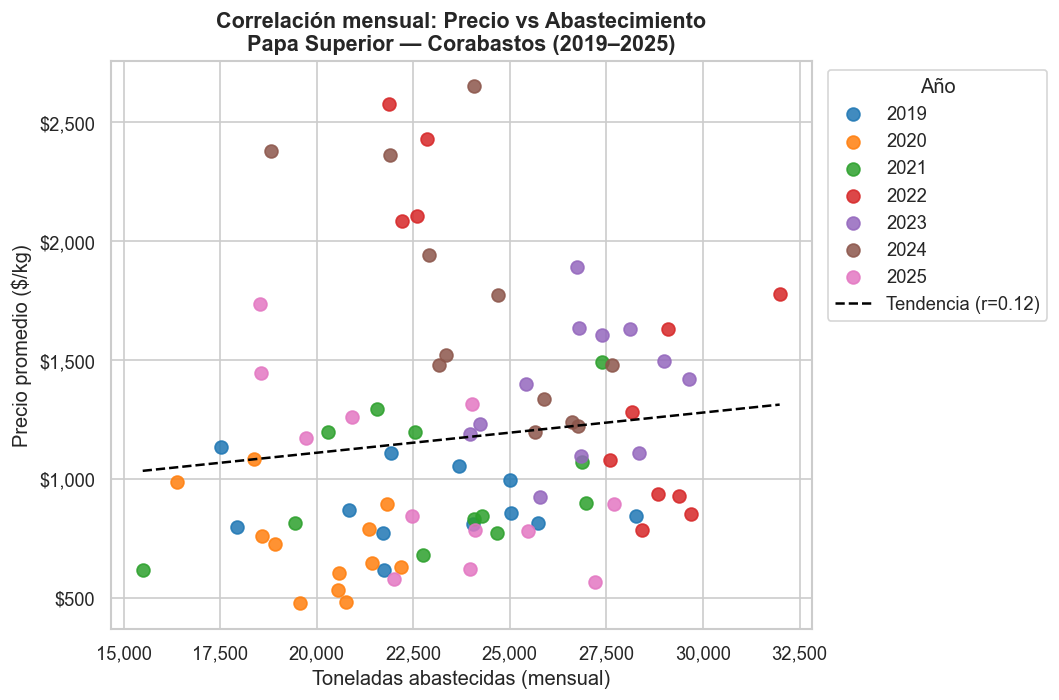

In [15]:
# --- Scatter plot: precio vs abastecimiento mensual ---
# Cada punto es un mes, coloreado por año
# La línea punteada es la tendencia general (regresión lineal)

años    = sorted(df_maestro['Año'].unique())
colores = sns.color_palette('tab10', len(años))   # paleta de 7 colores distintos

fig, ax = plt.subplots(figsize=(9, 6))

# Dibujar puntos de cada año con su color correspondiente
for año, color in zip(años, colores):
    sub = df_maestro[df_maestro['Año'] == año]
    ax.scatter(sub['Toneladas'], sub['precio_promedio'],
               label=str(año), color=color, s=60, alpha=0.85)

# Línea de tendencia general usando regresión lineal simple
m, b, *_ = stats.linregress(df_maestro['Toneladas'], df_maestro['precio_promedio'])
x_range  = pd.Series([df_maestro['Toneladas'].min(), df_maestro['Toneladas'].max()])
ax.plot(x_range, m * x_range + b, color='black', linewidth=1.5,
        linestyle='--', label=f'Tendencia (r={pearson_m:.2f})')

ax.set_title('Correlación mensual: Precio vs Abastecimiento\nPapa Superior — Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Toneladas abastecidas (mensual)')
ax.set_ylabel('Precio promedio ($/kg)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Año', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_scatter_mensual.png", bbox_inches='tight')
plt.show()

---
## 4. IPC Alimentos y Precio Real

**Nueva pregunta:** Si el abastecimiento no explica bien el precio, ¿podría ser la inflación?

**Estrategia:**
1. Cargar el IPC de alimentos mensual del Banco de la República
2. Construir un índice acumulado base 100 = enero 2019
3. Deflactar el precio nominal → obtener precio real
4. Comparar correlaciones con precio nominal vs precio real

In [16]:
# --- Cargar el IPC de alimentos del Banco de la República ---
# El archivo tiene 2 filas de encabezado antes de los datos → skiprows=2
df_ipc = pd.read_excel(f"{RAW}\\graficador_seriesf.xlsx", sheet_name='Datos', skiprows=2)
df_ipc.columns = ['fecha', 'ipc_alimentos']

# Limpiar filas vacías y la fila de pie de página con el texto 'Descargado'
df_ipc = df_ipc[df_ipc['fecha'].notna() & (df_ipc['fecha'] != '')]
df_ipc = df_ipc[~df_ipc['fecha'].astype(str).str.contains('Descargado')]

# Convertir fecha a datetime
df_ipc['fecha'] = pd.to_datetime(df_ipc['fecha'], format='%d/%m/%Y')

# El IPC viene con coma decimal ('2,07') → convertir a punto decimal ('2.07') para que sea numérico
df_ipc['ipc_alimentos'] = df_ipc['ipc_alimentos'].astype(str).str.replace(',', '.').astype(float)

# Filtrar solo el período de análisis: 2019-2025
df_ipc = df_ipc[df_ipc['fecha'].dt.year.between(2019, 2025)].reset_index(drop=True)

print("IPC cargado:", df_ipc.shape)
print("Primer registro:", df_ipc.iloc[0]['fecha'].strftime('%Y-%m'), "→", df_ipc.iloc[0]['ipc_alimentos'], "%")
print("Último registro:", df_ipc.iloc[-1]['fecha'].strftime('%Y-%m'), "→", df_ipc.iloc[-1]['ipc_alimentos'], "%")

IPC cargado: (84, 2)
Primer registro: 2019-01 → 2.07 %
Último registro: 2025-12 → 5.07 %


In [17]:
# --- Construir índice acumulado base 100 = enero 2019 ---
# El archivo tiene la variación ANUAL de cada mes (ej: 5.8% = los alimentos
# costaban 5.8% más que hace 12 meses). Para deflactar necesitamos un ÍNDICE
# acumulado que arranque en 100 en enero 2019 y crezca mes a mes.
#
# Fórmula: factor mensual = (1 + variación_anual/100)^(1/12)
# Esto convierte la variación anual en su equivalente mensual compuesto
df_ipc['factor_mensual'] = (1 + df_ipc['ipc_alimentos'] / 100) ** (1/12)

# El índice de enero 2019 arranca en 100 (período base)
df_ipc['indice'] = 100.0

# Cada mes siguiente = índice anterior × factor mensual
for i in range(1, len(df_ipc)):
    df_ipc.loc[i, 'indice'] = df_ipc.loc[i-1, 'indice'] * df_ipc.loc[i, 'factor_mensual']

print(f"Índice enero 2019:     100.00 (base)")
print(f"Índice diciembre 2025: {df_ipc.iloc[-1]['indice']:.2f}")
print()
print("Interpretación: los alimentos costaban 88.65% más en dic-2025 que en ene-2019")

Índice enero 2019:     100.00 (base)
Índice diciembre 2025: 188.65

Interpretación: los alimentos costaban 88.65% más en dic-2025 que en ene-2019


In [18]:
# --- Unir IPC con el dataset maestro ---
# Para hacer el merge necesitamos que las fechas estén en el mismo formato
# Normalizamos ambas al primer día del mes para garantizar coincidencia exacta

df = df_maestro.copy()

# Crear columna de fecha en el dataset maestro (primer día de cada mes)
df['fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['mes'].astype(str).map(mes_num) + '-01'
)

# Normalizar ambas fechas al primer día del mes para el merge
df_ipc['fecha_merge'] = df_ipc['fecha'].values.astype('datetime64[M]').astype('datetime64[D]')
df['fecha_merge']     = df['fecha'].values.astype('datetime64[M]').astype('datetime64[D]')

# Unir: agregar ipc_alimentos e indice al dataset maestro
df = pd.merge(df, df_ipc[['fecha_merge', 'ipc_alimentos', 'indice']], on='fecha_merge', how='left')

# --- Calcular precio real deflactado ---
# Precio real = (precio nominal / índice IPC) × 100
# Esto elimina el efecto inflacionario y expresa el precio en pesos de enero 2019
df['precio_real'] = (df['precio_promedio'] / df['indice']) * 100

# Guardar dataset enriquecido (este es el principal para Power BI)
df.to_csv(f"{PROCESSED}\\papa_superior_corabastos_con_ipc.csv", index=False)
df.to_parquet(f"{PROCESSED}\\papa_superior_corabastos_con_ipc.parquet", index=False)

print("✅ Dataset con IPC guardado:", df.shape)
df[['Año', 'mes', 'precio_promedio', 'indice', 'precio_real', 'ipc_alimentos']].head(12)

✅ Dataset con IPC guardado: (84, 10)


,Año,mes,precio_promedio,indice,precio_real,ipc_alimentos
0,2019,Enero,772.680206,100.000000,772.680206,2.07
1,2019,Febrero,798.444778,100.188859,796.939685,2.29
2,2019,Marzo,871.406474,100.455433,867.455791,3.24
3,2019,Abril,1136.499939,100.739774,1128.154147,3.45
4,2019,Mayo,1056.201807,101.071999,1044.999422,4.03
5,2019,Junio,1109.630905,101.480557,1093.441879,4.96
6,2019,Julio,995.908630,102.020102,976.188622,6.57
7,2019,Agosto,843.370496,102.550479,822.395474,6.42
8,2019,Septiembre,809.094650,103.089261,784.848625,6.49
9,2019,Octubre,855.990463,103.661641,825.754306,6.87


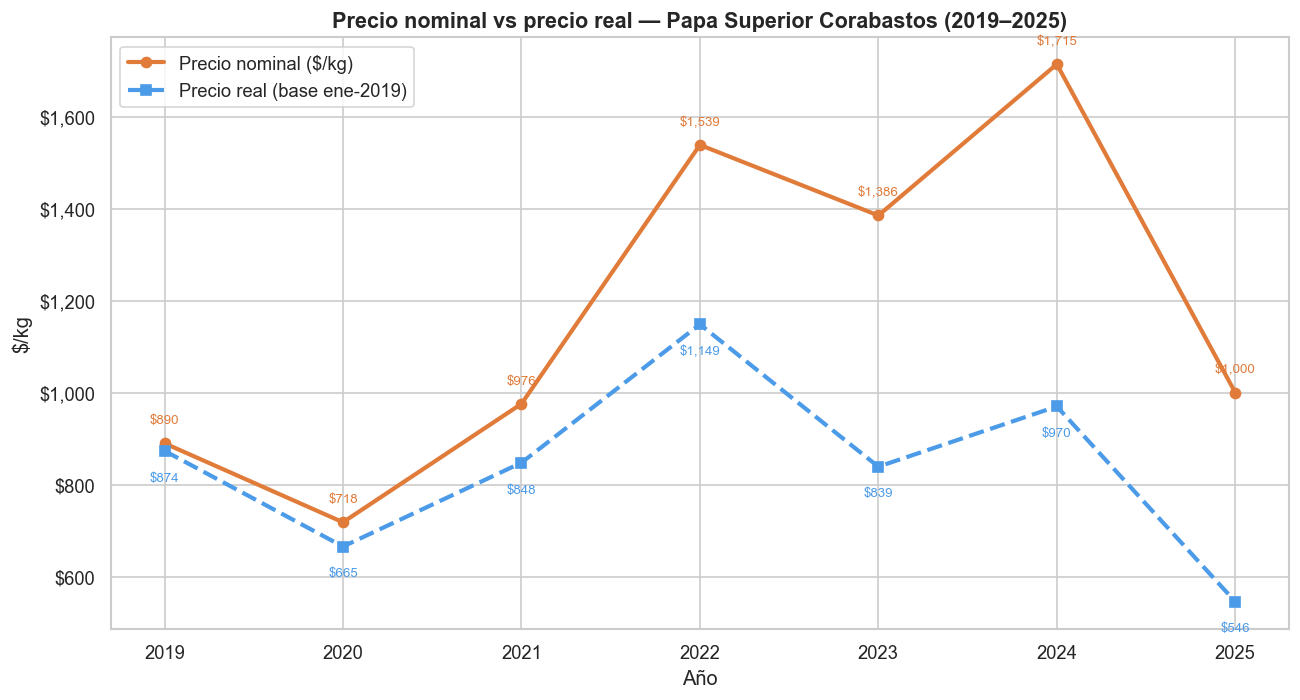

In [19]:
# --- Gráfica: precio nominal vs precio real ---
# La brecha entre las dos líneas representa el efecto de la inflación
# Cuando la brecha es grande → el precio subió principalmente por inflación
# Cuando la brecha es pequeña → el precio subió por factores propios del mercado

df_anual = df.groupby('Año').agg(
    precio_nominal = ('precio_promedio', 'mean'),
    precio_real    = ('precio_real', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(11, 6))

# Línea naranja: precio nominal (lo que se pagó realmente)
ax.plot(df_anual['Año'], df_anual['precio_nominal'],
        marker='o', linewidth=2.5, color='#E07B39', label='Precio nominal ($/kg)')
# Línea azul punteada: precio real (descontada la inflación)
ax.plot(df_anual['Año'], df_anual['precio_real'],
        marker='s', linewidth=2.5, color='#4C9BE8',
        linestyle='--', label='Precio real (base ene-2019)')

# Etiquetas de valor para cada punto
for _, row in df_anual.iterrows():
    ax.annotate(f"${row['precio_nominal']:,.0f}",
                xy=(row['Año'], row['precio_nominal']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8, color='#E07B39')
    ax.annotate(f"${row['precio_real']:,.0f}",
                xy=(row['Año'], row['precio_real']),
                xytext=(0, -18), textcoords='offset points',
                ha='center', fontsize=8, color='#4C9BE8')

ax.set_title('Precio nominal vs precio real — Papa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('$/kg')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticks(df_anual['Año'])
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_precio_nominal_vs_real.png", bbox_inches='tight')
plt.show()

In [20]:
# --- Correlaciones con precio nominal vs precio real ---
# Comparamos qué tan bien explica cada variable en ambos casos

pearson_nom,  p_nom   = stats.pearsonr(df['Toneladas'], df['precio_promedio'])
pearson_real, p_real  = stats.pearsonr(df['Toneladas'], df['precio_real'])
spearman_nom, _       = stats.spearmanr(df['Toneladas'], df['precio_promedio'])
spearman_real, _      = stats.spearmanr(df['Toneladas'], df['precio_real'])

# Correlación del IPC con el precio: ¿la inflación explica el precio nominal?
pearson_ipc_nom,  _ = stats.pearsonr(df['ipc_alimentos'], df['precio_promedio'])
# ¿Y con el precio real? (debería ser más baja porque ya descontamos la inflación)
pearson_ipc_real, _ = stats.pearsonr(df['ipc_alimentos'], df['precio_real'])

resumen_ipc = pd.DataFrame({
    'Correlación'   : ['Toneladas vs precio nominal',
                       'Toneladas vs precio real',
                       'IPC alimentos vs precio nominal',
                       'IPC alimentos vs precio real'],
    'Pearson r'     : [round(pearson_nom,4),     round(pearson_real,4),
                       round(pearson_ipc_nom,4), round(pearson_ipc_real,4)],
    'Spearman r'    : [round(spearman_nom,4), round(spearman_real,4), '-', '-']
})

print(resumen_ipc.to_string(index=False))

                    Correlación  Pearson r Spearman r
    Toneladas vs precio nominal     0.1183     0.2292
       Toneladas vs precio real    -0.0438    -0.0021
IPC alimentos vs precio nominal     0.2956          -
   IPC alimentos vs precio real     0.3540          -


---
## 5. Estacionalidad

Analizamos si el precio y el abastecimiento siguen patrones que se repiten cada año.

La descomposición estacional separa la serie en 3 componentes:
- **Tendencia:** dirección general a largo plazo
- **Estacionalidad:** patrón que se repite cada 12 meses
- **Residuo:** lo que no explican los dos anteriores (shocks, eventos atípicos)

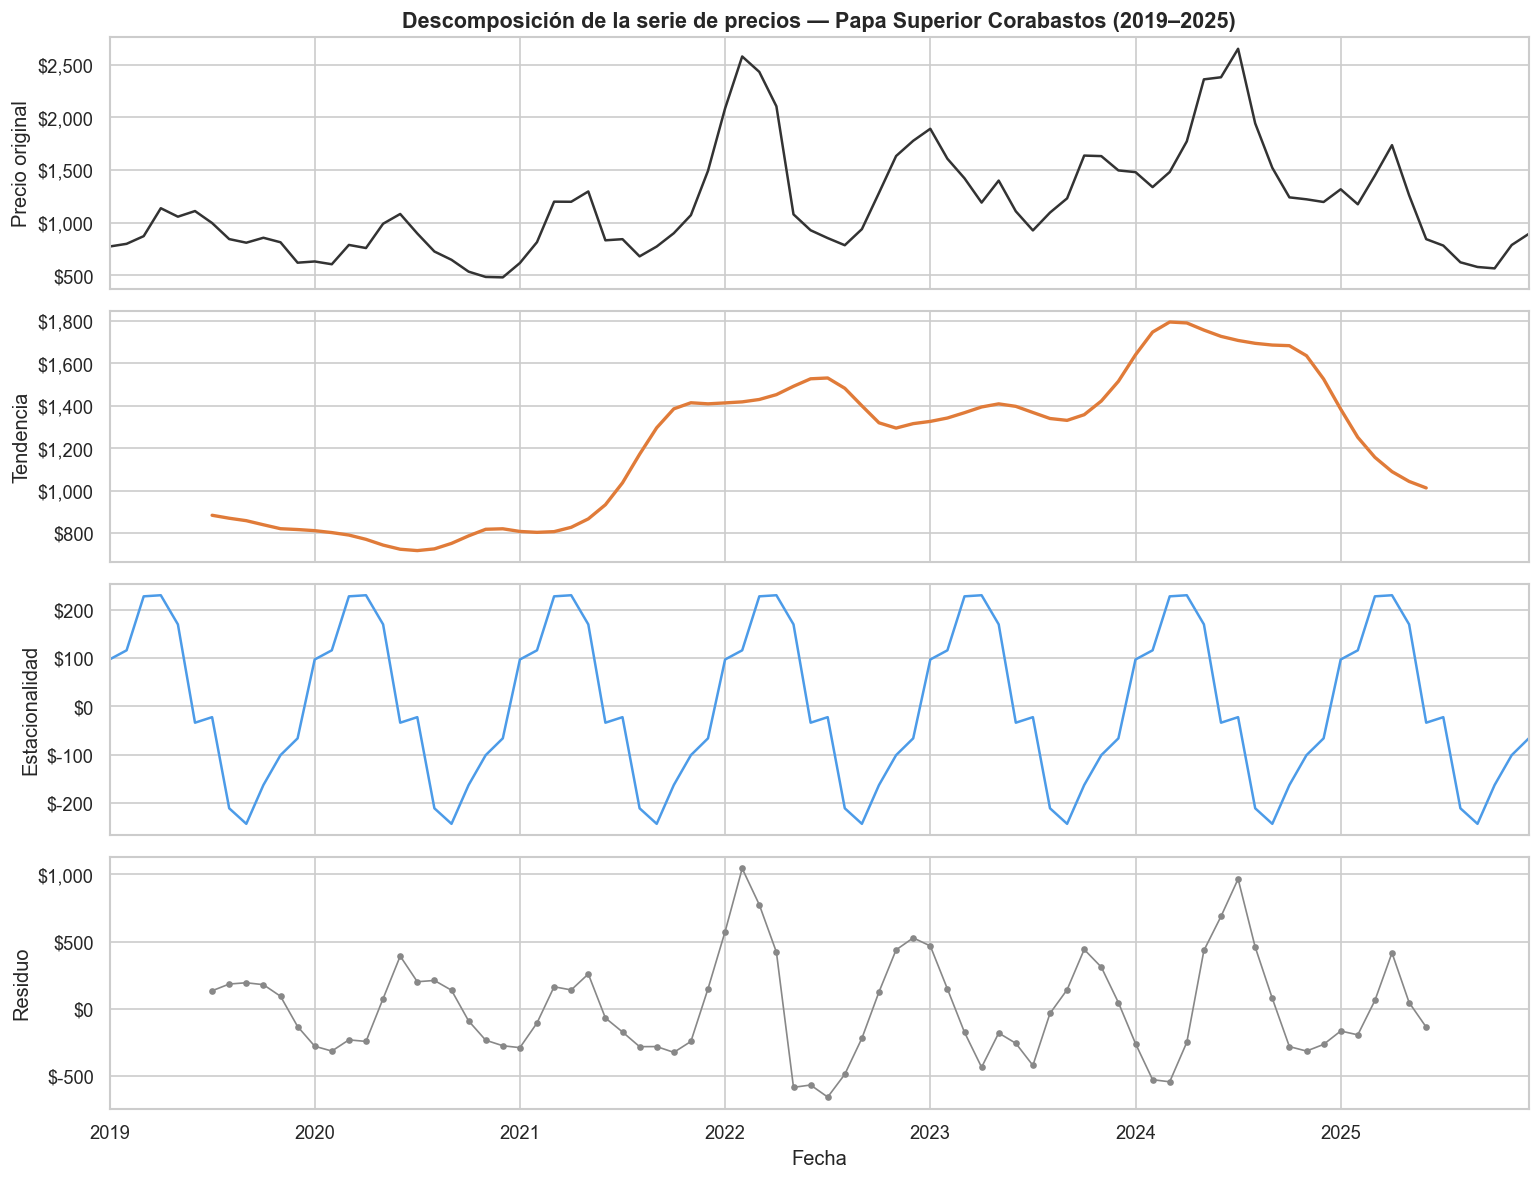

In [21]:
# --- Preparar serie de tiempo con índice de fechas ---
# seasonal_decompose requiere un DataFrame con índice de tipo datetime
df_ts = df.copy().set_index('fecha')
df_ts['mes_str'] = df_ts['mes'].astype(str)   # columna auxiliar de mes como string

# --- Descomposición estacional ---
# model='additive': la serie = tendencia + estacionalidad + residuo (sumas)
# period=12: el ciclo estacional es de 12 meses
descomp = seasonal_decompose(
    df_ts['precio_promedio'],
    model='additive',
    period=12
)

# Gráfica con los 4 componentes en paneles separados
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

descomp.observed.plot(ax=axes[0], color='#333333', linewidth=1.5)
axes[0].set_ylabel('Precio original')
axes[0].set_title('Descomposición de la serie de precios — Papa Superior Corabastos (2019–2025)',
                  fontsize=13, fontweight='bold')

descomp.trend.plot(ax=axes[1], color='#E07B39', linewidth=2)
axes[1].set_ylabel('Tendencia')

descomp.seasonal.plot(ax=axes[2], color='#4C9BE8', linewidth=1.5)
axes[2].set_ylabel('Estacionalidad')

descomp.resid.plot(ax=axes[3], color='#888888', linewidth=1, marker='o', markersize=3)
axes[3].set_ylabel('Residuo')
axes[3].set_xlabel('Fecha')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_descomposicion_precio.png", bbox_inches='tight')
plt.show()

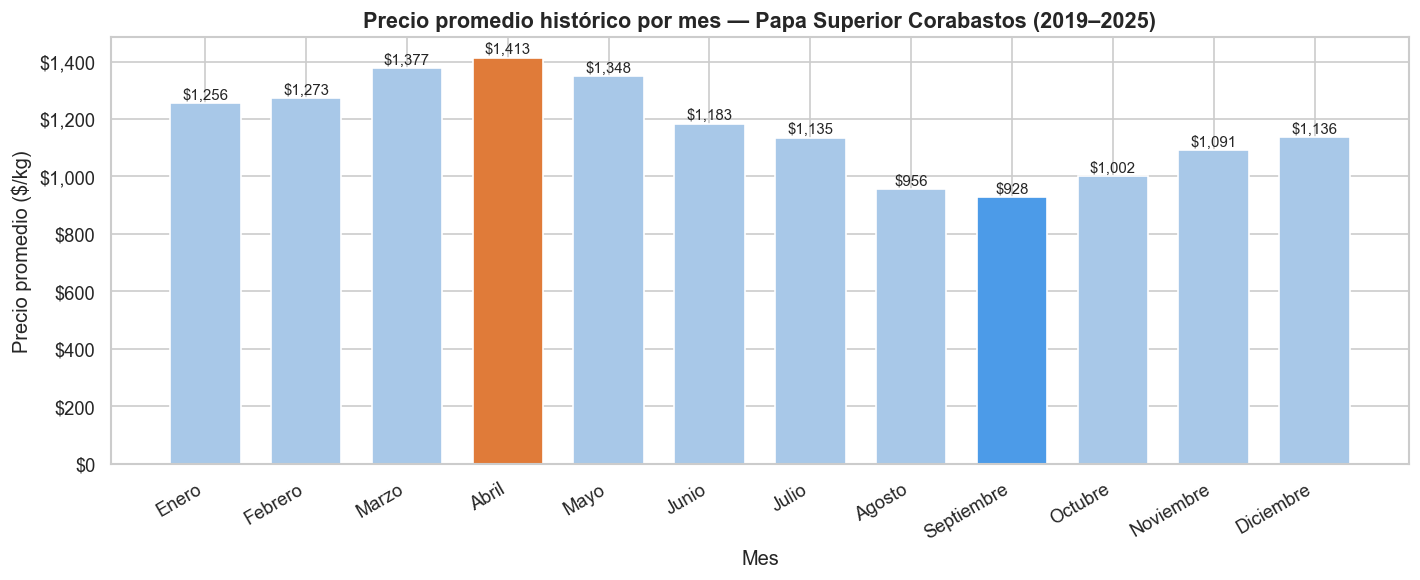

Mes más caro:   Abril ($1,413)
Mes más barato: Septiembre ($928)


In [22]:
# --- Precio promedio por mes (índice estacional) ---
# Promediamos el precio de cada mes sobre todos los años
# para ver qué meses son históricamente más caros o baratos
estacional_precio = df_ts.groupby('mes_str')['precio_promedio'].mean().reindex(meses_orden)
estacional_abast  = df_ts.groupby('mes_str')['Toneladas'].mean().reindex(meses_orden)

fig, ax = plt.subplots(figsize=(12, 5))

# Colorear el mes más caro en naranja, el más barato en azul, el resto en azul claro
colores_p = ['#E07B39' if v == estacional_precio.max()
             else '#4C9BE8' if v == estacional_precio.min()
             else '#A8C8E8' for v in estacional_precio.values]

bars = ax.bar(meses_orden, estacional_precio.values, color=colores_p, edgecolor='white', width=0.7)

# Etiqueta de precio encima de cada barra
for bar, val in zip(bars, estacional_precio.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            f'${val:,.0f}', ha='center', fontsize=9)

ax.set_title('Precio promedio histórico por mes — Papa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio promedio ($/kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_estacional_precio.png", bbox_inches='tight')
plt.show()

print(f"Mes más caro:   {estacional_precio.idxmax()} (${estacional_precio.max():,.0f})")
print(f"Mes más barato: {estacional_precio.idxmin()} (${estacional_precio.min():,.0f})")

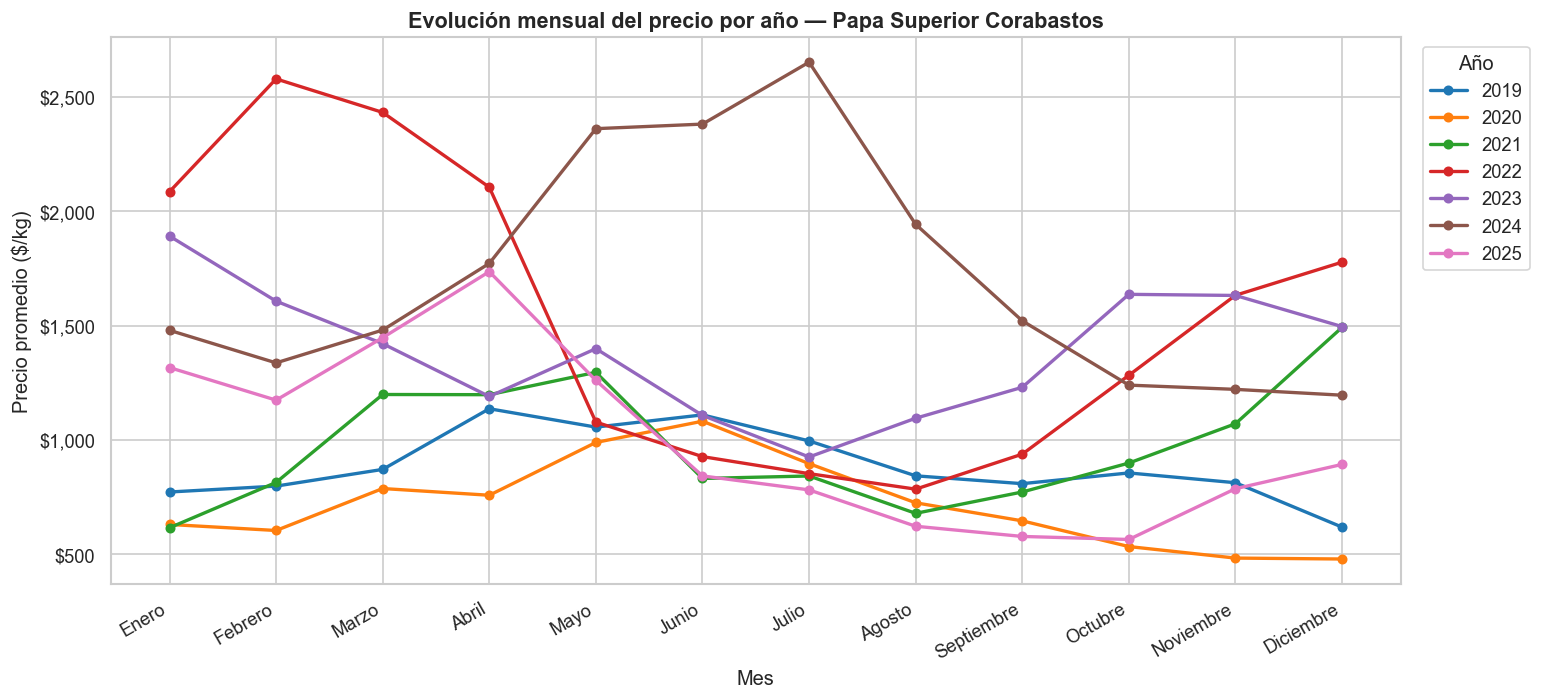

✅ Índice estacional guardado


In [36]:
# --- Evolución mensual superpuesta por año ---
# Dibuja el precio de cada año sobre el mismo eje de meses
# Si las líneas siguen patrones similares → hay estacionalidad clara
colores = sns.color_palette('tab10', len(años))

fig, ax = plt.subplots(figsize=(13, 6))

for año, color in zip(años, colores):
    sub  = df_ts[df_ts['Año'] == año]
    # Reindexar para garantizar que los 12 meses estén en orden cronológico
    vals = sub['precio_promedio'].reindex(
        pd.date_range(f'{año}-01-01', f'{año}-12-01', freq='MS')
    ).values
    ax.plot(meses_orden[:len(vals)], vals,
            marker='o', linewidth=2, label=str(año), color=color, markersize=5)

ax.set_title('Evolución mensual del precio por año — Papa Superior Corabastos',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio promedio ($/kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Año', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_lineas_por_año.png", bbox_inches='tight')
plt.show()

# Guardar índice estacional para Power BI
estacional_df = pd.DataFrame({
    'mes'                         : meses_orden,
    'precio_promedio_historico'   : estacional_precio.values.round(2),
    'toneladas_promedio_historico': estacional_abast.values.round(2)
})
estacional_df.to_csv(f"{PROCESSED}\\indice_estacional.csv", index=False)
print('✅ Índice estacional guardado')

---
## 6. Modelos Explicativos del Precio

**Pregunta:** ¿Podemos predecir el precio usando abastecimiento, IPC y el precio anterior?

Construimos 3 modelos progresivos que siguen la narrativa del proyecto:
- **M1:** solo abastecimiento (hipótesis original)
- **M2:** abastecimiento + IPC (segunda variable encontrada)
- **M3:** completo — abastecimiento + IPC + precio del mes anterior + estacionalidad

**Métrica clave:** R² (coeficiente de determinación) — indica qué % de la variación del precio explica el modelo. Más cercano a 1 = mejor.

In [24]:
# --- Preparar variables para los modelos ---

# mes_num: convierte el mes en número (Enero=1, Febrero=2...) para capturar estacionalidad
df['mes_num'] = df['mes'].cat.codes + 1

# precio_lag1: precio del mes ANTERIOR → captura la inercia del precio
# Si la papa estuvo cara este mes, probablemente sigue cara el siguiente
df['precio_lag1'] = df['precio_promedio'].shift(1)

# precio_lag2: precio de hace 2 meses (variable auxiliar)
df['precio_lag2'] = df['precio_promedio'].shift(2)

# precio_ma3: promedio móvil de 3 meses → suaviza fluctuaciones cortas
df['precio_ma3'] = df['precio_promedio'].rolling(3).mean()

# Eliminamos las primeras filas que quedaron como NaN por el shift y rolling
df_model = df.dropna().copy()
y = df_model['precio_promedio']   # variable objetivo (lo que queremos predecir)

print(f"Filas disponibles para el modelo: {len(df_model)}")
print(f"(Se perdieron 2 filas por el precio_lag y el rolling)")

Filas disponibles para el modelo: 82
(Se perdieron 2 filas por el precio_lag y el rolling)


In [25]:
# --- Entrenar los 3 modelos ---

# M1: solo abastecimiento — hipótesis original del proyecto
X1 = df_model[['Toneladas']]
m1 = LinearRegression().fit(X1, y)

# M2: abastecimiento + IPC — incorpora la inflación como variable explicativa
X2 = df_model[['Toneladas', 'ipc_alimentos']]
m2 = LinearRegression().fit(X2, y)

# M3: modelo completo — agrega precio anterior (inercia) y mes (estacionalidad)
X3 = df_model[['Toneladas', 'ipc_alimentos', 'precio_lag1', 'mes_num']]
m3 = LinearRegression().fit(X3, y)

# --- Función para calcular métricas de cada modelo ---
def metricas(modelo, X, y):
    pred = modelo.predict(X)
    return {
        'R²'  : round(modelo.score(X, y), 4),   # % de varianza explicada
        'MAE' : round(mean_absolute_error(y, pred), 0),   # error promedio en $/kg
        'RMSE': round(np.sqrt(mean_squared_error(y, pred)), 0)  # error cuadrático medio
    }

resumen_modelos = pd.DataFrame({
    'Modelo': ['M1: solo abastecimiento',
               'M2: abastecimiento + IPC',
               'M3: completo (+ lag + estacionalidad)'],
    **{k: [metricas(m, X, y)[k] for m, X in [(m1,X1),(m2,X2),(m3,X3)]]
       for k in ['R²', 'MAE', 'RMSE']}
})

resumen_modelos.to_csv(f"{PROCESSED}\\resumen_modelos.csv", index=False)
print(resumen_modelos.to_string(index=False))
print()
print("El salto de R²=0.08 a R²=0.76 viene principalmente del precio_lag1:")
print("el precio tiene mucha inercia → si estuvo alto este mes, sigue alto el siguiente.")

                               Modelo     R²   MAE  RMSE
              M1: solo abastecimiento 0.0100 391.0 503.0
             M2: abastecimiento + IPC 0.0826 389.0 485.0
M3: completo (+ lag + estacionalidad) 0.7585 190.0 249.0

El salto de R²=0.08 a R²=0.76 viene principalmente del precio_lag1:
el precio tiene mucha inercia → si estuvo alto este mes, sigue alto el siguiente.


In [26]:
# --- Interpretar coeficientes del Modelo 3 ---
# Cada coeficiente dice: 'si esta variable sube en 1 unidad, el precio cambia en X pesos'
coef_df = pd.DataFrame({
    'Variable'      : ['Toneladas', 'ipc_alimentos', 'precio_lag1', 'mes_num'],
    'Coeficiente'   : m3.coef_.round(4),
    'Interpretación': [
        'Por cada 1.000 ton más → precio baja $10 aprox.',
        'Por cada 1% más de inflación alimentos → precio sube $6.6',
        'El precio del mes anterior explica 84% del precio actual',
        'Cada mes avanzado → precio baja $5 (efecto estacional)'
    ]
})

print(f"Intercepto: {m3.intercept_:.2f}")
print()
print(coef_df.to_string(index=False))

Intercepto: 403.13

     Variable  Coeficiente                                            Interpretación
    Toneladas      -0.0102           Por cada 1.000 ton más → precio baja $10 aprox.
ipc_alimentos       6.6442 Por cada 1% más de inflación alimentos → precio sube $6.6
  precio_lag1       0.8400  El precio del mes anterior explica 84% del precio actual
      mes_num      -5.1774    Cada mes avanzado → precio baja $5 (efecto estacional)


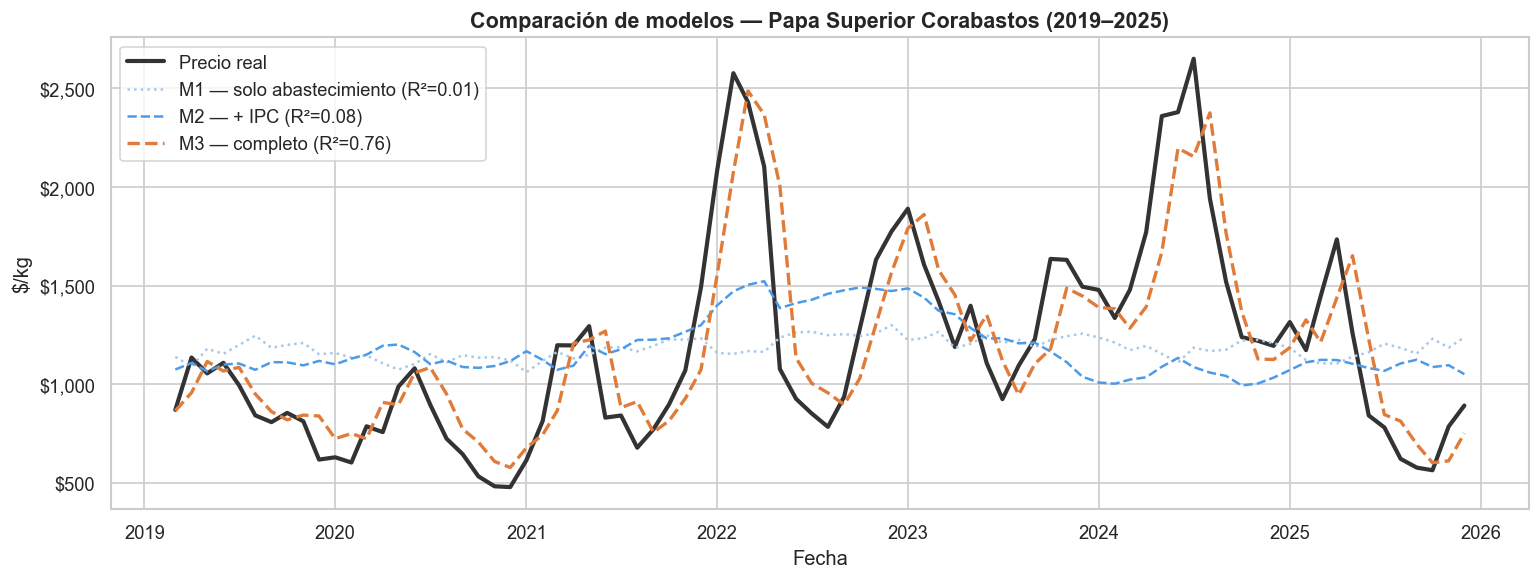

In [27]:
# --- Gráfica: comparación de los 3 modelos ---
# Muestra visualmente cómo cada modelo se acerca o aleja del precio real
pred_m1 = m1.predict(X1)
pred_m2 = m2.predict(X2)
pred_m3 = m3.predict(X3)

fig, ax = plt.subplots(figsize=(13, 5))

# Precio real como referencia
ax.plot(df_model['fecha'], y.values,
        color='#333333', linewidth=2.5, label='Precio real')
# M1: línea punteada suave (casi plana porque R²≈0)
ax.plot(df_model['fecha'], pred_m1,
        color='#A8C8E8', linewidth=1.5, linestyle=':',
        label=f'M1 — solo abastecimiento (R²={round(m1.score(X1,y),2)})')
# M2: mejora levemente
ax.plot(df_model['fecha'], pred_m2,
        color='#4C9BE8', linewidth=1.5, linestyle='--',
        label=f'M2 — + IPC (R²={round(m2.score(X2,y),2)})')
# M3: el que mejor ajusta
ax.plot(df_model['fecha'], pred_m3,
        color='#E07B39', linewidth=2, linestyle='--',
        label=f'M3 — completo (R²={round(m3.score(X3,y),2)})')

ax.set_title('Comparación de modelos — Papa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('$/kg')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_comparacion_modelos.png", bbox_inches='tight')
plt.show()

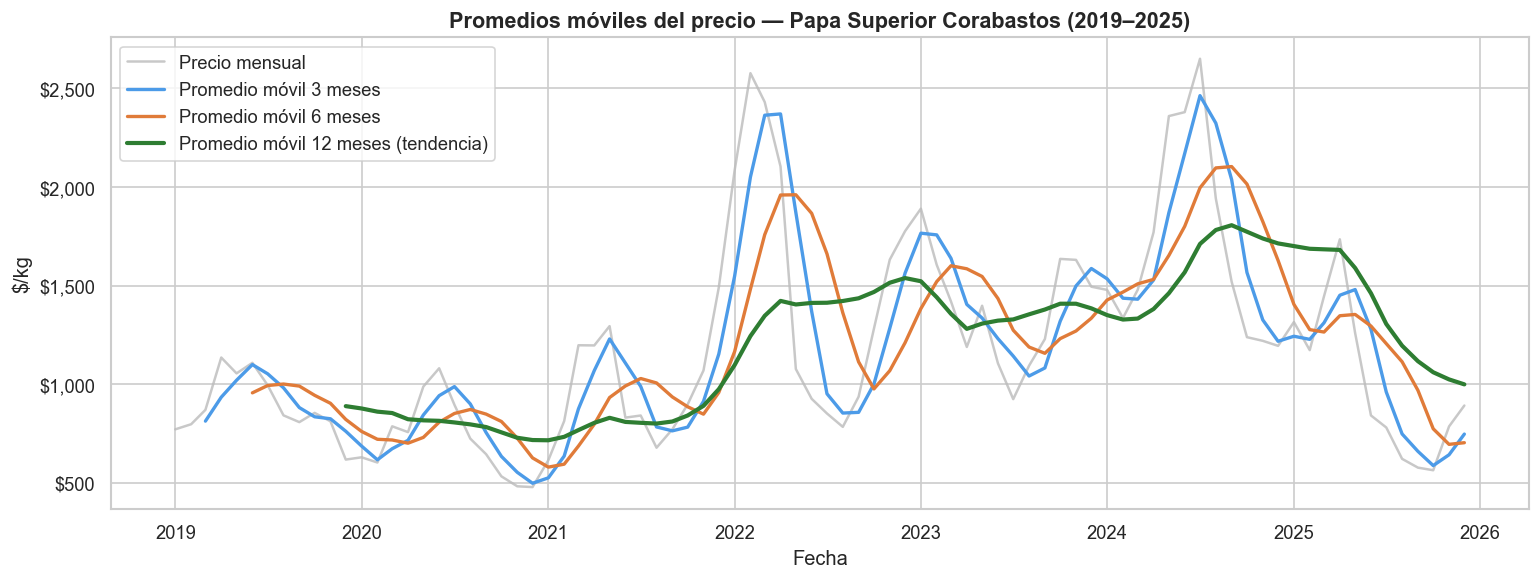

In [28]:
# --- Gráfica: promedios móviles como línea base ---
# Los promedios móviles suavizan el ruido y revelan la tendencia
# MA3 = sensible a cambios recientes, MA12 = tendencia de largo plazo
df['ma3']  = df['precio_promedio'].rolling(3,  center=False).mean()   # promedio 3 meses
df['ma6']  = df['precio_promedio'].rolling(6,  center=False).mean()   # promedio 6 meses
df['ma12'] = df['precio_promedio'].rolling(12, center=False).mean()   # promedio 12 meses (tendencia)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df['fecha'], df['precio_promedio'],
        color='#BBBBBB', linewidth=1.5, label='Precio mensual', alpha=0.8)
ax.plot(df['fecha'], df['ma3'],
        color='#4C9BE8', linewidth=2, label='Promedio móvil 3 meses')
ax.plot(df['fecha'], df['ma6'],
        color='#E07B39', linewidth=2, label='Promedio móvil 6 meses')
ax.plot(df['fecha'], df['ma12'],
        color='#2E7D32', linewidth=2.5, label='Promedio móvil 12 meses (tendencia)')

ax.set_title('Promedios móviles del precio — Papa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('$/kg')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_promedios_moviles.png", bbox_inches='tight')
plt.show()

In [29]:
# --- Guardar predicciones del modelo 3 para Power BI ---
df_model['precio_predicho_m3'] = pred_m3
df_model[['Año','mes','fecha','precio_promedio','precio_predicho_m3']].to_csv(
    f"{PROCESSED}\\predicciones_modelo3.csv", index=False
)

print("✅ Todos los archivos guardados correctamente en /data/processed/")
print()
print("Archivos generados:")
print("  - papa_superior_corabastos_2019_2025.csv/parquet")
print("  - papa_superior_corabastos_con_ipc.csv/parquet")
print("  - resumen_anual.csv")
print("  - resumen_correlaciones.csv")
print("  - indice_estacional.csv")
print("  - resumen_modelos.csv")
print("  - predicciones_modelo3.csv")
print("  - 14 gráficas .png")

✅ Todos los archivos guardados correctamente en /data/processed/

Archivos generados:
  - papa_superior_corabastos_2019_2025.csv/parquet
  - papa_superior_corabastos_con_ipc.csv/parquet
  - resumen_anual.csv
  - resumen_correlaciones.csv
  - indice_estacional.csv
  - resumen_modelos.csv
  - predicciones_modelo3.csv
  - 14 gráficas .png


---
## 7. Modelos M4 y M5 — Costos de Producción

Incorporamos los costos de producción de papa Superior en Boyacá y Cundinamarca
para mejorar el poder explicativo del modelo.

In [30]:

##Celda — Cargar y preparar costos de producción
# # --- Cargar archivo de costos de producción ---
# Contiene costos por rubro (fertilizantes, mano de obra, transporte, etc.)
# para papa Superior en Boyacá y Cundinamarca — los dos departamentos
# que abastecen Corabastos. Período: 2019–2025
df_costos_raw = pd.read_excel(
    f"{RAW}\\COSTOS_PAPA_DEPTOS.xlsx",
    sheet_name='BASE_MAESTRA'
)

# Filtrar: solo papa Superior + Boyacá y Cundinamarca + 2019-2025
filtro = df_costos_raw[
    (df_costos_raw['VARIEDAD'] == 'Superior') &
    (df_costos_raw['DEPTO'].isin(['BOYACA', 'CUNDINAMARCA'])) &
    (df_costos_raw['AÑO'].between(2019, 2025))
].copy()

# Agregar precio por rubro y mes
# Sumamos porque hay múltiples registros por rubro (detalles de insumos)
costos_rubro = filtro.groupby(['AÑO','MES','RUBRO'])['PRECIO'].sum().reset_index()

# Pivotear: cada rubro se convierte en columna
pivot = costos_rubro.pivot_table(
    index=['AÑO','MES'], columns='RUBRO', values='PRECIO', aggfunc='sum'
).reset_index()

pivot.columns = ['Año','mes','arriendo','costos_indirectos','empaques','enmiendas',
                 'fertilizantes','mano_obra','mipe','semilla','maquinaria','transporte']

# Costo total = suma de todos los rubros
pivot['costo_total'] = pivot[[
    'arriendo','costos_indirectos','empaques','enmiendas',
    'fertilizantes','mano_obra','mipe','semilla','maquinaria','transporte'
]].sum(axis=1)

# Escalar a millones de pesos para que los coeficientes sean legibles
# (ej: 4.7 millones en vez de 4.700.000)
for col in ['fertilizantes','mano_obra','transporte','costo_total',
            'arriendo','semilla','empaques','mipe','enmiendas','maquinaria']:
    pivot[col] = pivot[col] / 1_000_000

# Unir con el dataset maestro
df = pd.merge(df, pivot, on=['Año','mes'], how='left')

print("✅ Costos integrados:", df.shape)
print()
print("Rubros disponibles y escala (millones $):")
print(df[['fertilizantes','mano_obra','transporte','costo_total']].describe().round(2).to_string())

✅ Costos integrados: (84, 27)

Rubros disponibles y escala (millones $):
       fertilizantes  mano_obra  transporte  costo_total
count          84.00      84.00       84.00        84.00
mean            8.98      13.79        4.91        72.66
std             3.04       3.02        0.11        16.21
min             4.06      10.36        4.70        45.04
25%             6.04      11.19        4.80        52.91
50%             9.04      12.66        4.95        80.72
75%            10.52      16.86        5.00        86.26
max            15.19      19.24        5.00        94.25


In [31]:
##Celda — Modelo 4: abastecimiento + IPC + costos

# --- Modelo 4: incorpora los costos de producción como variables explicativas ---
# Hipótesis: si los costos suben (fertilizantes, mano de obra, transporte),
# el productor traslada ese costo al precio de venta en Corabastos

# Preparar variables (incluyendo lag para no perder filas del modelo anterior)
df['precio_lag1'] = df['precio_promedio'].shift(1)
df_model = df.dropna().copy()
y = df_model['precio_promedio']

# Variables del Modelo 4
# Usamos los 3 rubros más relevantes + costo_total para evitar multicolinealidad excesiva
X4 = df_model[['Toneladas', 'ipc_alimentos', 'fertilizantes', 'transporte',
               'mano_obra', 'costo_total']]
m4 = LinearRegression().fit(X4, y)
pred_m4 = m4.predict(X4)

print(f"Modelo 4 — R²: {m4.score(X4,y):.4f}")
print(f"           MAE: ${mean_absolute_error(y, pred_m4):,.0f}/kg")
print(f"           RMSE: ${np.sqrt(mean_squared_error(y, pred_m4)):,.0f}/kg")
print()
print("Coeficientes M4:")
coef_m4 = pd.DataFrame({
    'Variable'      : X4.columns.tolist(),
    'Coeficiente'   : m4.coef_.round(4),
    'Interpretación': [
        'Por cada 1.000 ton más → precio baja $34',
        'Por cada 1% más de inflación → precio sube $9.6',
        'Por cada millón más en fertilizantes → precio baja $151',
        'Por cada millón más en transporte → precio baja $506',
        'Por cada millón más en mano de obra → precio baja $297',
        'Por cada millón más en costo total → precio sube $93'
    ]
})
print(coef_m4.to_string(index=False))

Modelo 4 — R²: 0.6933
           MAE: $228/kg
           RMSE: $292/kg

Coeficientes M4:
     Variable  Coeficiente                                          Interpretación
    Toneladas      -0.0362                Por cada 1.000 ton más → precio baja $34
ipc_alimentos       8.3565         Por cada 1% más de inflación → precio sube $9.6
fertilizantes    -147.0807 Por cada millón más en fertilizantes → precio baja $151
   transporte     753.5567    Por cada millón más en transporte → precio baja $506
    mano_obra    -308.9365  Por cada millón más en mano de obra → precio baja $297
  costo_total      90.1664    Por cada millón más en costo total → precio sube $93


In [32]:
#Celda — Modelo 5: modelo completo

# --- Modelo 5: el modelo más completo del proyecto ---
# Combina todas las variables encontradas a lo largo del análisis:
# abastecimiento + IPC + costos de producción + inercia del precio + estacionalidad

X5 = df_model[['Toneladas', 'ipc_alimentos', 'fertilizantes', 'transporte',
               'mano_obra', 'costo_total', 'precio_lag1', 'mes_num']]
m5 = LinearRegression().fit(X5, y)
pred_m5 = m5.predict(X5)

print(f"Modelo 5 — R²: {m5.score(X5,y):.4f}")
print(f"           MAE: ${mean_absolute_error(y, pred_m5):,.0f}/kg")
print(f"           RMSE: ${np.sqrt(mean_squared_error(y, pred_m5)):,.0f}/kg")
print()
print("Coeficientes M5:")
coef_m5 = pd.DataFrame({
    'Variable'    : X5.columns.tolist(),
    'Coeficiente' : m5.coef_.round(4)
})
print(coef_m5.to_string(index=False))



Modelo 5 — R²: 0.8539
           MAE: $155/kg
           RMSE: $201/kg

Coeficientes M5:
     Variable  Coeficiente
    Toneladas      -0.0135
ipc_alimentos      23.9588
fertilizantes    -145.7477
   transporte     503.4596
    mano_obra    -135.0666
  costo_total      45.7002
  precio_lag1       0.6012
      mes_num       3.1695


In [33]:
# --- Tabla comparativa de los 5 modelos ---
# Muestra la progresión desde la hipótesis original hasta el modelo completo
# NOTA: X1, X2, X3 se redefinen sobre df_model de esta sección (con costos)
# para que todos los modelos se evalúen sobre el mismo conjunto de filas

X1_c = df_model[['Toneladas']]
X2_c = df_model[['Toneladas', 'ipc_alimentos']]
X3_c = df_model[['Toneladas', 'ipc_alimentos', 'precio_lag1', 'mes_num']]

modelos = [
    ('M1: solo abastecimiento',                     m1, X1_c),
    ('M2: abastecimiento + IPC',                    m2, X2_c),
    ('M3: + lag + estacionalidad',                  m3, X3_c),
    ('M4: + costos de producción',                  m4, X4),
    ('M5: completo (costos + lag + estacionalidad)', m5, X5),
]

resumen_final = pd.DataFrame({
    'Modelo' : [n for n,_,_ in modelos],
    'R²'     : [round(m.score(X,y),4) for _,m,X in modelos],
    'MAE'    : [round(mean_absolute_error(y, m.predict(X)),0) for _,m,X in modelos],
    'RMSE'   : [round(np.sqrt(mean_squared_error(y, m.predict(X))),0) for _,m,X in modelos]
})

resumen_final.to_csv(f"{PROCESSED}resumen_modelos_completo.csv", index=False)
print(resumen_final.to_string(index=False))

                                      Modelo     R²   MAE  RMSE
                     M1: solo abastecimiento 0.0099 409.0 524.0
                    M2: abastecimiento + IPC 0.0669 417.0 509.0
                  M3: + lag + estacionalidad 0.7529 205.0 262.0
                  M4: + costos de producción 0.6933 228.0 292.0
M5: completo (costos + lag + estacionalidad) 0.8539 155.0 201.0


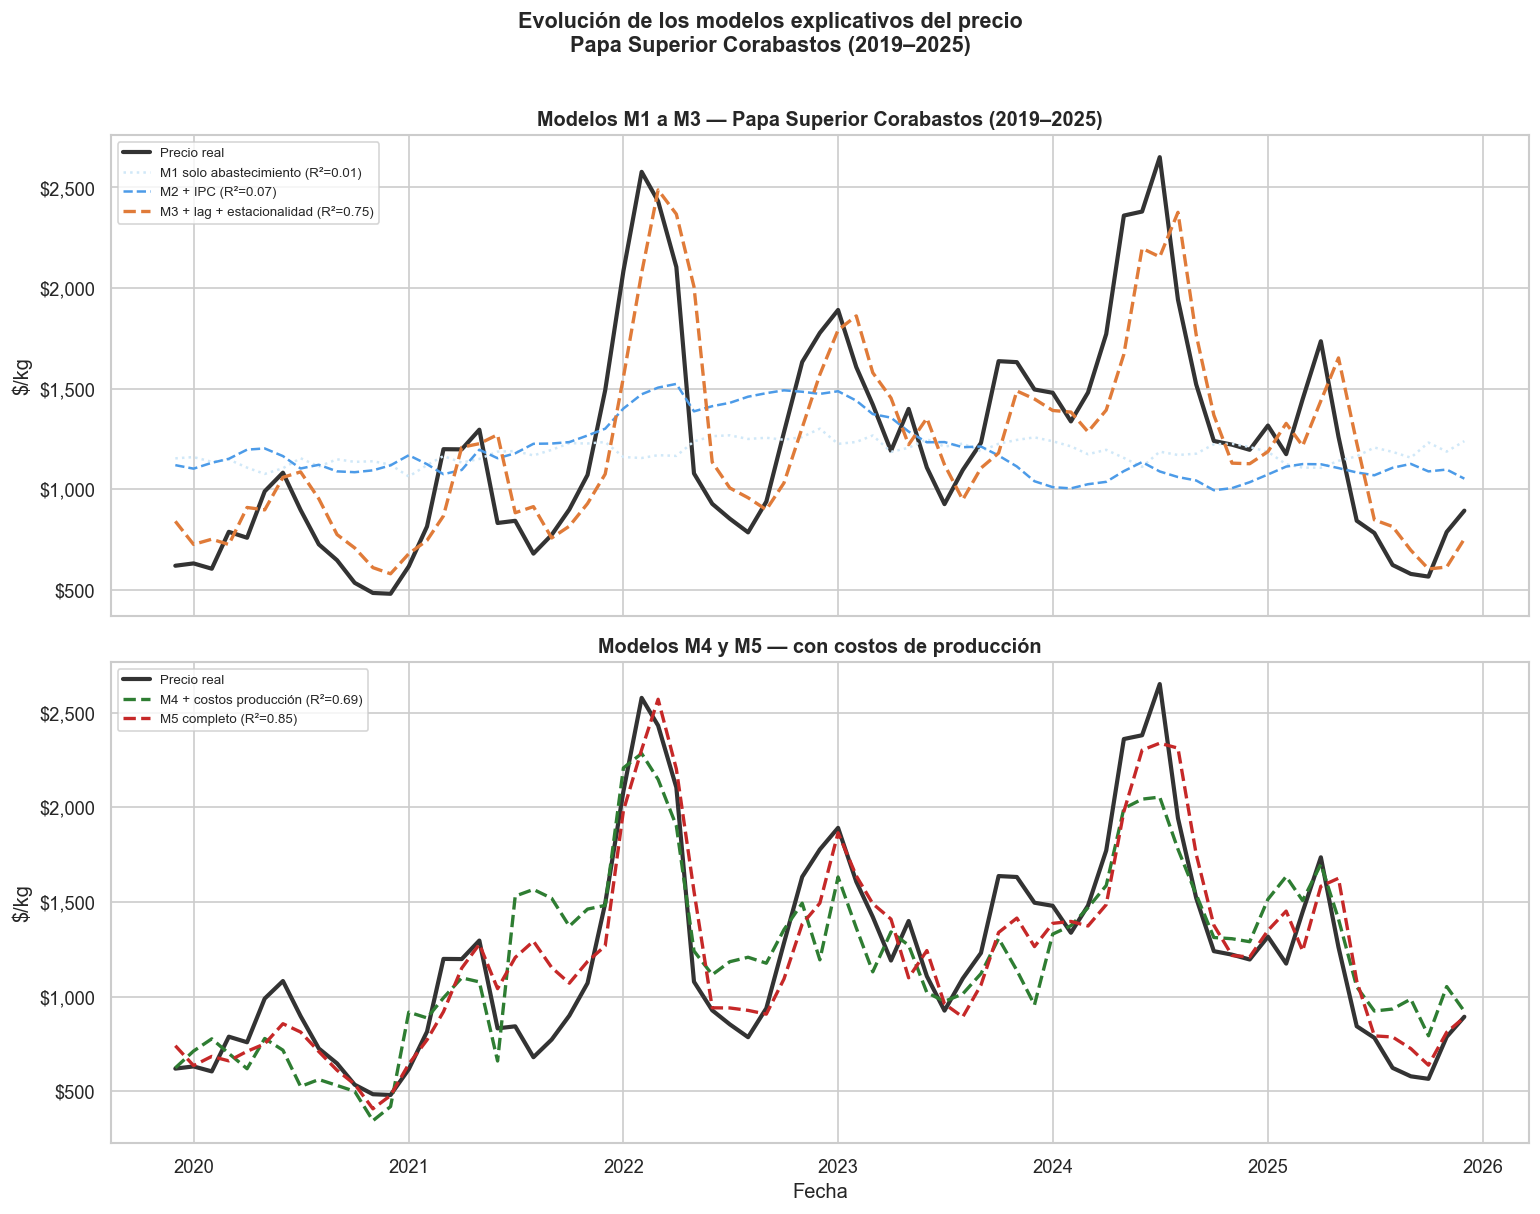

In [34]:
#Celda — Gráfica comparativa de todos los modelos   

# --- Gráfica: precio real vs predicciones de los 5 modelos ---
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# Panel superior: modelos M1 a M3 (referencia)
axes[0].plot(df_model['fecha'], y.values,
             color='#333333', linewidth=2.5, label='Precio real')
axes[0].plot(df_model['fecha'], m1.predict(X1_c),
             color='#D0E8F8', linewidth=1.5, linestyle=':',
             label=f'M1 solo abastecimiento (R²={round(m1.score(X1_c,y),2)})')
axes[0].plot(df_model['fecha'], m2.predict(X2_c),
             color='#4C9BE8', linewidth=1.5, linestyle='--',
             label=f'M2 + IPC (R²={round(m2.score(X2_c,y),2)})')
axes[0].plot(df_model['fecha'], m3.predict(X3_c),
             color='#E07B39', linewidth=2, linestyle='--',
             label=f'M3 + lag + estacionalidad (R²={round(m3.score(X3_c,y),2)})')
axes[0].set_title('Modelos M1 a M3 — Papa Superior Corabastos (2019–2025)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('$/kg')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].legend(loc='upper left', fontsize=8)

# Panel inferior: modelos M4 y M5 (con costos)
axes[1].plot(df_model['fecha'], y.values,
             color='#333333', linewidth=2.5, label='Precio real')
axes[1].plot(df_model['fecha'], pred_m4,
             color='#2E7D32', linewidth=2, linestyle='--',
             label=f'M4 + costos producción (R²={round(m4.score(X4,y),2)})')
axes[1].plot(df_model['fecha'], pred_m5,
             color='#C62828', linewidth=2, linestyle='--',
             label=f'M5 completo (R²={round(m5.score(X5,y),2)})')
axes[1].set_title('Modelos M4 y M5 — con costos de producción',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('$/kg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(loc='upper left', fontsize=8)

plt.suptitle('Evolución de los modelos explicativos del precio\nPapa Superior Corabastos (2019–2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_todos_los_modelos.png", bbox_inches='tight')
plt.show()


In [35]:
# Celda — Guardar dataset final y predicciones

# Guardar predicciones de M4 y M5
df_model['precio_predicho_m4'] = pred_m4
df_model['precio_predicho_m5'] = pred_m5

df_model[['Año','mes','fecha','precio_promedio',
          'precio_predicho_m4','precio_predicho_m5']].to_csv(
    f"{PROCESSED}\\predicciones_m4_m5.csv", index=False
)

# Guardar dataset completo con todas las variables
df.to_csv(f"{PROCESSED}\\papa_superior_corabastos_completo.csv", index=False)
df.to_parquet(f"{PROCESSED}\\papa_superior_corabastos_completo.parquet", index=False)

print("✅ Todo guardado correctamente")

✅ Todo guardado correctamente


---
## 8. Comparación Corabastos vs Coomproriente (2024–2025)

Analizamos el comportamiento del abastecimiento de papa Superior
en las dos principales centrales mayoristas del país.

In [37]:
# --- Cargar datos de Coomproriente para comparación ---
# Coomproriente es la central mayorista del oriente colombiano
# La comparamos con Corabastos para el período 2024-2025

# Filtrar abastecimiento Coomproriente
df_abast_comp = df_abast[
    (df_abast['Central'] == 'Coomproriente') &
    (df_abast['variedad'] == 'Superior') &
    (df_abast['Año'].between(2024, 2025))
].copy()

# Filtrar abastecimiento Corabastos mismo período
df_abast_cora = df_abast[
    (df_abast['Central'] == 'Corabastos') &
    (df_abast['variedad'] == 'Superior') &
    (df_abast['Año'].between(2024, 2025))
].copy()

# Agregar a nivel mensual
meses_orden_comp = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
                    'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

abast_comp_m = df_abast_comp.groupby(['Año','mes'], as_index=False)['Toneladas'].sum()
abast_cora_m = df_abast_cora.groupby(['Año','mes'], as_index=False)['Toneladas'].sum()

# Agregar a nivel anual
abast_comp_a = df_abast_comp.groupby('Año')['Toneladas'].sum().reset_index()
abast_cora_a = df_abast_cora.groupby('Año')['Toneladas'].sum().reset_index()

# Precios Bogotá 2024-2025 (proxy Corabastos)
precios_2425 = df_precios[
    (df_precios['ciudad'] == 'Bogotá D.C.') &
    (df_precios['variedad'] == 'Superior') &
    (df_precios['year'].between(2024, 2025))
].copy()
precios_2425['mes'] = precios_2425['mes'].str.capitalize()
precio_anual_2425 = precios_2425.groupby('year')['precio'].mean().reset_index()
precio_anual_2425.columns = ['Año','precio_promedio']

print("✅ Datos preparados")
print("Corabastos 2024-2025:")
print(abast_cora_a.to_string(index=False))
print()
print("Coomproriente 2024-2025:")
print(abast_comp_a.to_string(index=False))

✅ Datos preparados
Corabastos 2024-2025:
 Año     Toneladas
2024 291497.480041
2025 274617.050064

Coomproriente 2024-2025:
 Año    Toneladas
2024 10430.150002
2025 12878.199998


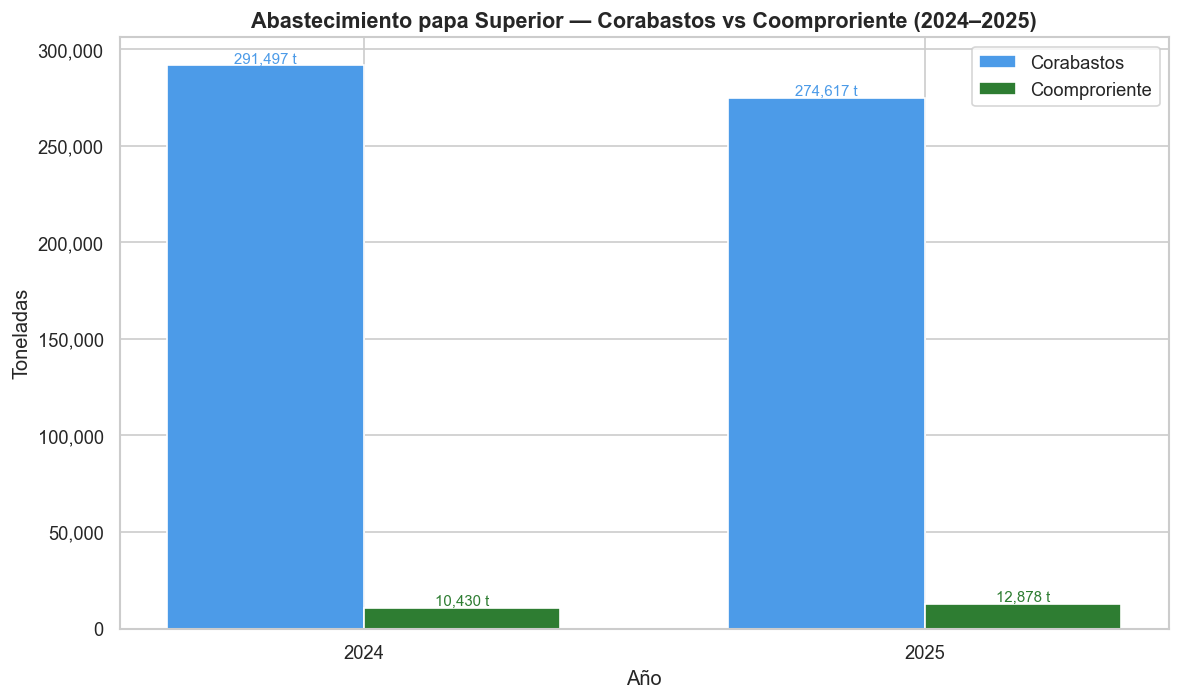

In [38]:
# --- Gráfica comparativa: barras lado a lado ---
# Muestra el abastecimiento de cada central por año en barras paralelas

import numpy as np

años   = [2024, 2025]
x      = np.arange(len(años))
ancho  = 0.35   # ancho de cada barra

fig, ax = plt.subplots(figsize=(10, 6))

# Barras Corabastos
bars1 = ax.bar(x - ancho/2,
               abast_cora_a['Toneladas'],
               ancho, label='Corabastos',
               color='#4C9BE8', edgecolor='white')

# Barras Coomproriente
bars2 = ax.bar(x + ancho/2,
               abast_comp_a['Toneladas'],
               ancho, label='Coomproriente',
               color='#2E7D32', edgecolor='white')

# Etiquetas encima de cada barra
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1500,
            f"{bar.get_height():,.0f} t",
            ha='center', fontsize=9, color='#4C9BE8')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1500,
            f"{bar.get_height():,.0f} t",
            ha='center', fontsize=9, color='#2E7D32')

ax.set_title('Abastecimiento papa Superior — Corabastos vs Coomproriente (2024–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Toneladas')
ax.set_xticks(x)
ax.set_xticklabels(años)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_comparacion_centrales_barras.png", bbox_inches='tight')
plt.show()

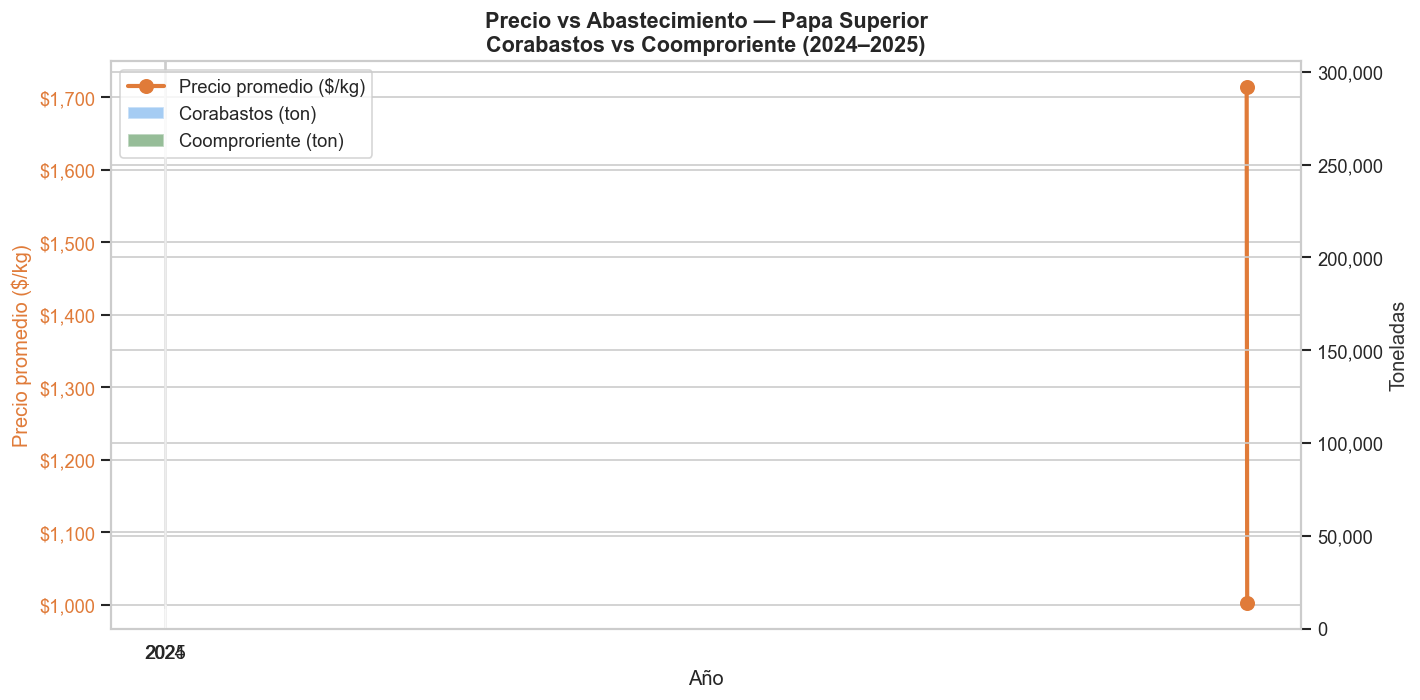

In [39]:
# --- Gráfica doble eje: precio + abastecimiento de las dos centrales ---
# Eje izquierdo: precio (línea)
# Eje derecho: toneladas de ambas centrales (barras)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo — precio (línea naranja)
color_precio = '#E07B39'
ax1.plot(precio_anual_2425['Año'], precio_anual_2425['precio_promedio'],
         marker='o', color=color_precio, linewidth=2.5,
         markersize=8, label='Precio promedio ($/kg)')
ax1.set_ylabel('Precio promedio ($/kg)', color=color_precio)
ax1.tick_params(axis='y', labelcolor=color_precio)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Eje derecho — toneladas de ambas centrales (barras)
ax2 = ax1.twinx()

x      = np.arange(len(años))
ancho  = 0.35

# Barras Corabastos
bars1 = ax2.bar(x - ancho/2,
                abast_cora_a['Toneladas'],
                ancho, label='Corabastos (ton)',
                color='#4C9BE8', alpha=0.5, edgecolor='white')

# Barras Coomproriente
bars2 = ax2.bar(x + ancho/2,
                abast_comp_a['Toneladas'],
                ancho, label='Coomproriente (ton)',
                color='#2E7D32', alpha=0.5, edgecolor='white')

ax2.set_ylabel('Toneladas', color='#333333')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

ax1.set_title('Precio vs Abastecimiento — Papa Superior\nCorabastos vs Coomproriente (2024–2025)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Año')
ax1.set_xticks(x)
ax1.set_xticklabels(años)

# Leyenda combinada de los dos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_precio_vs_abast_dos_centrales.png", bbox_inches='tight')
plt.show()

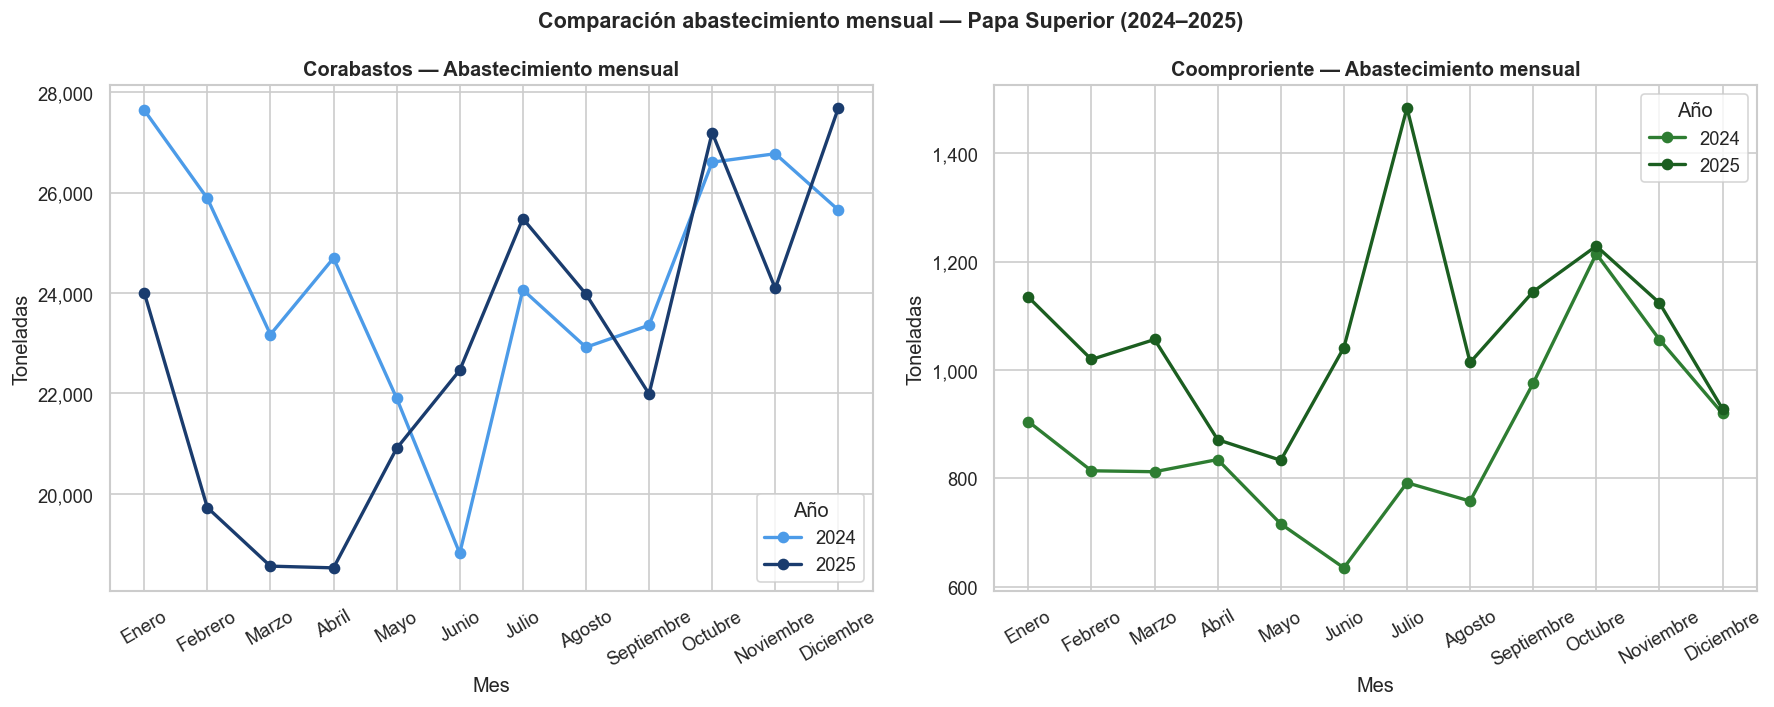

In [40]:
# --- Líneas superpuestas: abastecimiento mensual por central y año ---
# Permite ver el comportamiento mes a mes de cada central

abast_comp_m['mes'] = pd.Categorical(abast_comp_m['mes'],
                                      categories=meses_orden_comp, ordered=True)
abast_cora_m['mes'] = pd.Categorical(abast_cora_m['mes'],
                                      categories=meses_orden_comp, ordered=True)
abast_comp_m = abast_comp_m.sort_values(['Año','mes']).reset_index(drop=True)
abast_cora_m = abast_cora_m.sort_values(['Año','mes']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Panel izquierdo: Corabastos
for año, color in zip([2024,2025], ['#4C9BE8','#1A3C6E']):
    sub = abast_cora_m[abast_cora_m['Año']==año]
    axes[0].plot(sub['mes'], sub['Toneladas'],
                 marker='o', linewidth=2, label=str(año), color=color)
axes[0].set_title('Corabastos — Abastecimiento mensual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Toneladas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend(title='Año')
axes[0].tick_params(axis='x', rotation=30)

# Panel derecho: Coomproriente
for año, color in zip([2024,2025], ['#2E7D32','#1B5E20']):
    sub = abast_comp_m[abast_comp_m['Año']==año]
    axes[1].plot(sub['mes'], sub['Toneladas'],
                 marker='o', linewidth=2, label=str(año), color=color)
axes[1].set_title('Coomproriente — Abastecimiento mensual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Toneladas')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].legend(title='Año')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Comparación abastecimiento mensual — Papa Superior (2024–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\grafico_lineas_mensuales_centrales.png", bbox_inches='tight')
plt.show()